# Analyze and plot the results of linear treadmill with reward simulation

### Import

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
scenario = "linear_shock"
trial_number = 10
use_example = True
save_plot = False

In [3]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
data_path = os.path.join(base_path,"data",scenario)
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "example" if use_example else "trial"

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(trial_number)

# Add the directory to sys.path
ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)

from global_variables import *
from linear_shock_variables import *
from linear_shock_functions import *
from plots import *

# Fig. 6, Aversive stimuli learning 

### Fig. 6c, Perceived salience

In [ ]:
target_lap = np.arange(4)+1; feat_lap = 4
feat_state = num_state_total-1; feat_ID = 1
feat_speed = feature_speed[feat_ID]

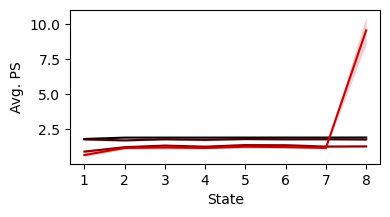

In [7]:
windows_per_state = steps_per_unit*np.ones((len(target_lap),num_state_total),dtype=int)
windows_per_state[target_lap==feat_lap,feat_state] = int(steps_per_unit/feat_speed)

windows_per_state = np.cumsum(windows_per_state,axis=1)
windows_per_state = np.hstack((np.zeros((len(target_lap),1),dtype=int),windows_per_state))

PS_arr = list()
mean_PS = np.zeros((len(target_lap),num_state_total,len(target_seed)))

for jj, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    for ee, load_lap in enumerate(target_lap):
        PS_lap = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))["PS_list"]
        PS_arr.append(PS_lap)
        
        for ss in range(num_state_total):
            if np.any(np.isnan(PS_lap)): print(PS_lap[np.isnan(PS_lap)])
            mean_PS[ee,ss,jj] = np.mean(PS_lap[windows_per_state[ee,ss]:windows_per_state[ee,ss+1]])

        del PS_lap

colors = create_gradient([0,0,0],[0.8,0,0],len(target_lap))
fig, ax = plt.subplots(1,1,figsize=(4,2))
for ii, ee in enumerate(target_lap):
    plot_shaded(np.arange(num_state_total)+1, mean_PS.mean(-1)[ii], mean_PS.std(-1)[ii], ax=ax, color=colors[ii])

ax.set_xticks(np.arange(num_state_total)+1); ax.set_xlabel("State"); ax.set_ylabel("Avg. PS")
if save_plot: plt.savefig(os.path.join(plot_path,"Average_PS.png"), dpi=300)
plt.show()

### Fig. 6d, Emergence of place cells

In [8]:
load_lap = 4
seed = target_seed[0]
foldername = folder_root + str(seed)

CA1_activity = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["CA1_activity"]
CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(load_lap)+".pkl"))

place_field_sorted_idx = np.array(list(CA1_PF.keys()))
place_div_idx = np.hstack((place_field_sorted_idx,np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)))

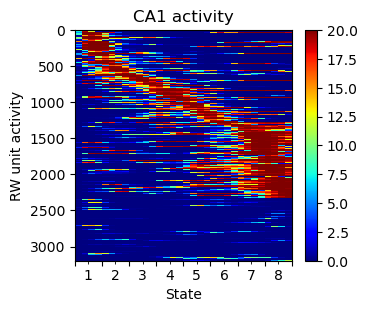

In [9]:
xlab = []

for ii in range(num_state_total):
    xlab.append("%d"%(ii))

data = CA1_activity[:, place_div_idx].T
x = np.arange(data.shape[1] + 1)
y = np.arange(data.shape[0] + 1)

#place_field_sorted_idx
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
fig, ax = plot_heatmap(data, fig, ax, title="CA1 activity", cmap="jet", vmin=0, vmax=max_input_FR)
plt.gca().yaxis.set_inverted(True)
ax.set_xlabel("State"); ax.set_ylabel("Neuron"); ax.set_xticklabels([])
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
ax.set_xticks(x_ticks); ax.set_xticklabels([])
ax.set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("RW unit activity"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 6f, Spontaneous off-site offline activity

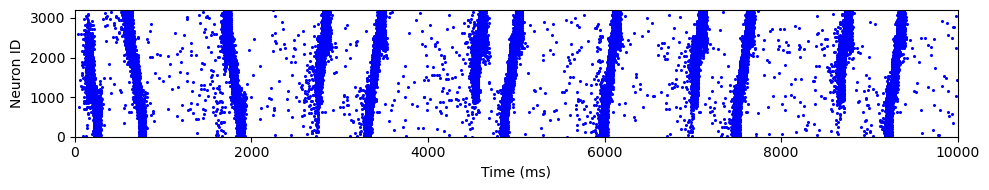

In [13]:
example_seed = target_seed[7]; load_lap = 4

CA3_PF = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_PF.keys()),dtype=int), np.array(list(CA3_PF.values())))
target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,np.arange(num_state_col))

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"CA3_replay_lap_%d.npz"%(load_lap)))
spike_times_CA3_PC = ff['spike_times_CA3_PC']; spiking_neurons_CA3_PC = ff['spiking_neurons_CA3_PC']; rate_CA3_PC = ff['rate_CA3_PC']
del ff

fig, ax = plt.subplots(1,1,figsize=(10,2))
plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx, zoom_to=rest_time, ax=ax)
ax.set_ylim([0, num_CA3_neurons])

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Spontaneous_offsite_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 6g, Predicted presence of shock at each state

In [95]:
replay_lap = 4
unit_gran = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d.npz"%replay_lap))["unit_gran"]
feat_pred = np.zeros((len(target_seed),len(target_lap),num_state_total,num_features))
feat_pred_replay = np.zeros((len(target_seed),num_state_total,num_features))

In [105]:
for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)
    
    for ee, load_lap in enumerate(target_lap):
        w_CA1_feat = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))["w_CA1_feat"]
        CA1_activity = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d.npz"%(load_lap)))["CA1_activity"]
        feat_pred_temp = CA1_activity@w_CA1_feat
        for ss in range(num_state_total):
            feat_pred[mm,ee,ss] = np.mean(feat_pred_temp[ss*unit_gran:(ss+1)*unit_gran],axis=0)
        # del CA1_activity, feat_pred_temp

        if load_lap == replay_lap:
            CA1_rep_activity = np.load(os.path.join(data_path,foldername,"activity/CA1_lap_%d_0_9999_replayed.npz"%(load_lap)))["CA1_activity"]
            feat_pred_temp = (CA1_rep_activity@w_CA1_feat)
            for ss in range(num_state_total): 
                feat_pred_replay[mm,ss] = np.mean(feat_pred_temp[ss*unit_gran:(ss+1)*unit_gran],axis=0)
            # del w_CA1_feat, CA1_rep_activity, feat_pred_temp

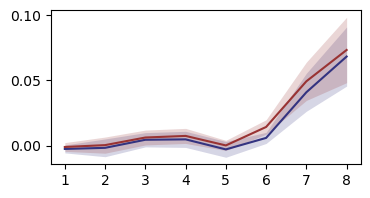

In [106]:
colorTheme = [[0,.7,.5],[.2,.2,.5],[.6,.2,.2]]

fig, ax = plt.subplots(1,1,figsize=(4, 2))

xx = np.arange(num_state_total)+1

ax = plot_shaded(xx, feat_pred[:,feat_lap-1,:,feat_ID].mean(0), feat_pred[:,feat_lap-1,:,feat_ID].std(0),color=colorTheme[1],ax=ax)
ax = plot_shaded(xx, feat_pred_replay[:,:,feat_ID].mean(0), feat_pred_replay[:,:,feat_ID].std(0),color=colorTheme[2],ax=ax)

ax.set_xticks(np.linspace(1,num_state_total,num_state_total))
ax.set_yticks(np.arange(-.0,.11,.05))
if save_plot: plt.savefig(os.path.join(plot_path,"predicted_presence_shock.svg"), format="svg")
plt.show()

In [107]:
for ss in range(num_state_total):
    _,p_val = stats.ttest_rel(feat_pred[:,replay_lap-1,ss,feat_ID],feat_pred_replay[:,ss,feat_ID])
    print("Bf replay vs. after replay, state %d, p_val:"%(ss+1),p_val)

Bf replay vs. after replay, state 1, p_val: 0.0028904268058073347
Bf replay vs. after replay, state 2, p_val: 0.05624531576853474
Bf replay vs. after replay, state 3, p_val: 0.0012482154705005678
Bf replay vs. after replay, state 4, p_val: 0.013313871149799567
Bf replay vs. after replay, state 5, p_val: 0.0323019727990707
Bf replay vs. after replay, state 6, p_val: 4.265808600576991e-06
Bf replay vs. after replay, state 7, p_val: 0.0010553865908509478
Bf replay vs. after replay, state 8, p_val: 0.03536615749811021


### Fig. 6h, Markov transition matrices before and after offline learning

In [108]:
num_behav_trial = 100
total_time = 600
possible_actions = np.array([[0,-1],[0,0],[0,1]])  # left, stay, right


In [146]:
value_arr = np.zeros((len(target_seed),3,num_state_total))           
for mm in range(len(target_seed)):
    value_arr[mm,0] = feat_pred[mm,replay_lap-2]@value_vector*50
    value_arr[mm,1] = feat_pred[mm,replay_lap-1]@value_vector*50
    value_arr[mm,2] = feat_pred_replay[mm]@value_vector*50

transition_matrix = np.zeros((len(target_seed), value_arr.shape[-1], num_state_total, num_state_total))

for mm in range(len(target_seed)):
    for vv in range(value_arr.shape[1]):
        transition_matrix[mm,vv,:,:], _ = compute_transition_matrix(num_state_total,value_arr[mm,vv],possible_actions)


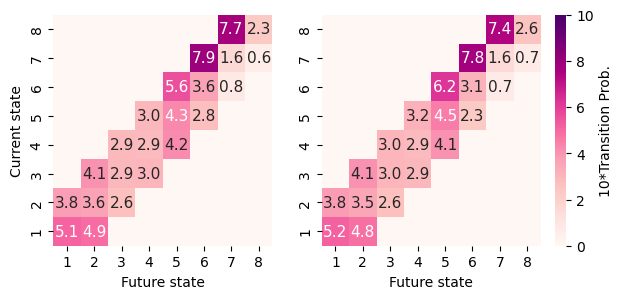

In [150]:
fig, axs = plt.subplots(1,2,width_ratios=(4,5),figsize=(7, 3))
annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[1])
sns.heatmap(10*transition_matrix.mean(0)[1], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[0],vmax=10,cbar=False)
axs[0].set_xticklabels(np.arange(1,num_state_total+1)); axs[0].set_yticklabels(np.arange(1,num_state_total+1))
axs[0].invert_yaxis(); axs[0].set_ylabel("Current state"); axs[0].set_xlabel("Future state")

annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[2])
sns.heatmap(10*transition_matrix.mean(0)[2], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[1],vmax=10,cbar_kws={'label': '10*Transition Prob.'})
axs[1].set_xticklabels(np.arange(1,num_state_total+1)); axs[1].set_yticklabels(np.arange(1,num_state_total+1))
axs[1].invert_yaxis(); axs[1].set_xlabel("Future state")

if save_plot: plt.savefig(os.path.join(plot_path,"transition_matrix.png"), dpi=300)
plt.show()


### Fig. 6i, Simulated behavioral phase

In [155]:
num_behav_trial = 100
total_time = 600

trajectory_arr = np.zeros((value_arr.shape[1],len(target_seed),total_time,num_behav_trial))
SZ_occupancy = np.zeros((value_arr.shape[1],len(target_seed),num_behav_trial))
SH_occupancy = np.zeros((value_arr.shape[1],len(target_seed),num_behav_trial))
for mm in range(len(target_seed)):
    for tt in range(num_behav_trial):
        for vv in range(value_arr.shape[1]):
            trajectory_arr[vv,mm,:,tt],_,_ = behavior_markov(transition_matrix[mm,vv], total_time=total_time, start_state=0)
            SZ_occupancy[vv,mm,tt] = np.sum(trajectory_arr[vv,mm,:,tt]==feat_state)/total_time
            SH_occupancy[vv,mm,tt] = np.sum((trajectory_arr[vv,mm,:,tt]>=num_state_total//2)&(trajectory_arr[vv,mm,:,tt]<=feat_state))/total_time


In [156]:
colors = [[0,.7,.5],[.2,.2,.5],[.6,.2,.2]]

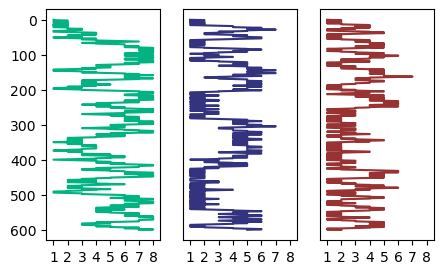

In [157]:
plot_tr = 20
load_seed = 2

fig, axs = plt.subplots(1,3,figsize=(5,3))
for xx in range(value_arr.shape[1]):
    axs[xx].plot(trajectory_arr[xx,load_seed,:,plot_tr]+1,np.arange(total_time),color=colors[xx]); axs[xx].set_xlim([.5,num_state_total+.5]); axs[xx].set_xticks(np.arange(1,num_state_total+1)); axs[xx].invert_yaxis()
    if xx>0: axs[xx].set_yticks([])

if save_plot: plt.savefig(os.path.join(plot_path,"simulated_behavior.png"), dpi=300)
plt.show()

### Fig. 6j, Near-shock-zone occupancy

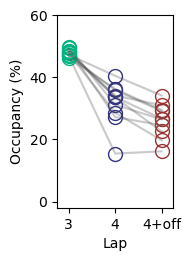

In [168]:
np.squeeze(SH_occupancy)
plt.figure(figsize=(1.5, 2.5))
xx = np.arange(3)+1

for seed in range(len(target_seed)):
    data = SH_occupancy[:,seed,:].mean(-1)*100
    plt.plot(np.arange(3)+1, data, '-', color=[.3,.3,.3,.3])
    for cc in range(3):
        plt.plot([cc+1], data[cc], 'o', markersize = 10, markerfacecolor=(0,0,0,0), markeredgecolor=colors[cc])

plt.xlim([0.75,3.25]); plt.xticks([1,2,3],[]); plt.ylim([-2,60])
plt.xticks([1,2,3],['3','4','4+off']); plt.xlabel("Lap"); plt.ylabel("Occupancy (%)")
if save_plot: plt.savefig(os.path.join(plot_path,"near_shock_occupancy.png"), dpi=300)
plt.show()

In [164]:
_, p_val = stats.ttest_rel(SH_occupancy[0].flatten(),SH_occupancy[1].flatten())
print("no shock vs. shock wo offline, p val:",p_val)

_, p_val = stats.ttest_rel(SH_occupancy[1].flatten(),SH_occupancy[2].flatten())
print("shock wo offline vs. shock w offline, p val:",p_val)

_, p_val = stats.ttest_rel(SH_occupancy[0].flatten(),SH_occupancy[2].flatten())
print("no shock vs. shock w offline, p val:",p_val)

no shock vs. shock wo offline, p val: 1.4628650913994391e-170
shock wo offline vs. shock w offline, p val: 4.591596169720159e-52
no shock vs. shock w offline, p val: 3.9657478343624577e-284


### Fig. 6l, On-site offline activity

In [ ]:
example_seed = target_seed[0]; load_lap = 4; pause_state = 4

CA3_PF = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_PF.keys()),dtype=int), np.array(list(CA3_PF.values())))
target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,np.arange(num_state_col))

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"CA3_replay_lap_%d_pause_%d.npz"%(load_lap, pause_state)))
spike_times_CA3_PC = ff['spike_times_CA3_PC']; spiking_neurons_CA3_PC = ff['spiking_neurons_CA3_PC']; rate_CA3_PC = ff['rate_CA3_PC']
del ff

replay, replay_results = analyse_replay(spike_times_CA3_PC, spiking_neurons_CA3_PC, rate_CA3_PC)

Detecting replay:   0%|          | 0/4 [00:00<?, ?it/s]

Detecting replay: 100%|██████████| 4/4 [00:12<00:00,  3.22s/it]

Replay detected!


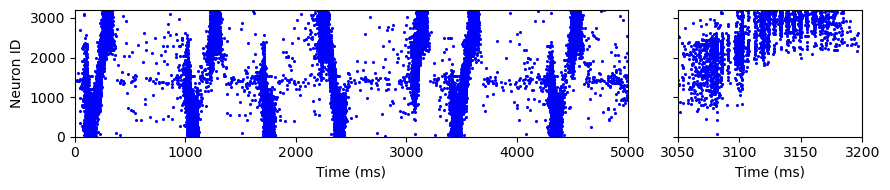

In [37]:
fig,axs = plt.subplots(1,2,figsize=(9,2), width_ratios=[3, 1], sharey=True)

plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx,
               zoom_from=0, zoom_to=5000, ax=axs[0])
axs[0].set_ylim([0, num_CA3_neurons])

roll_out_time = [3050,3200]
plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx,
               zoom_from=roll_out_time[0], zoom_to=roll_out_time[1], ax=axs[1])
axs[1].set_ylim([0, num_CA3_neurons]); axs[1].set_ylabel("")

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Onsite_replay_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 6m, Accessing shock presence information through forward roll-out

In [97]:
window = 100

file_in = os.path.join(data_path,foldername,"CA1_replay_lap_%d_pause_%d.npz"%(load_lap, pause_state))
ff = np.load(file_in); spk_time = ff["spike_times_CA1_PC"]; spk_neuron = ff["spiking_neurons_CA1_PC"]
del ff

w_CA1_feat = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]

select_idx = np.where((spk_time>(roll_out_time[0]-window))&(spk_time<roll_out_time[1]))[0]
spk_time = spk_time[select_idx]
spk_neuron = spk_neuron[select_idx]

pred = np.zeros(roll_out_time[1]-roll_out_time[0])
for tt in range(roll_out_time[1]-roll_out_time[0]):
    select_idx = np.where((spk_time>(tt+roll_out_time[0]-window))&(spk_time<(tt+roll_out_time[0])))[0]
    pred[tt] = np.sum(w_CA1_feat[spk_neuron[select_idx],1])*(1000//window)

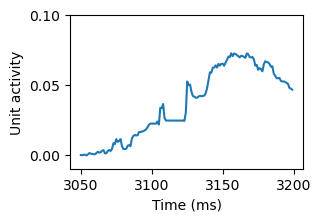

In [100]:
plt.figure(figsize=(3, 2))
plt.plot(np.arange(roll_out_time[0],roll_out_time[1]),pred)
plt.ylim([-0.01,0.1]); plt.yticks([0,0.05,0.1]); plt.xlabel("Time (ms)"); plt.ylabel("Unit activity")
if save_plot: plt.savefig(os.path.join(plot_path,"rollout_prediction.png"), dpi=300)
plt.show()